In [2]:
import pandas as pd


In [3]:
df5=pd.read_csv("../2FeatureEngineering/FeatureEngineering.csv")
df5.head(10)

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
5,Whitefield,2 BHK,1170.0,2.0,38.00,2,3247.863248
6,Old Airport Road,4 BHK,2732.0,4.0,204.00,4,7467.057101
7,Rajaji Nagar,4 BHK,3300.0,4.0,600.00,4,18181.818182
8,Marathahalli,3 BHK,1310.0,3.0,63.25,3,4828.244275
9,other,6 Bedroom,1020.0,6.0,370.00,6,36274.509804


In [4]:
df5[df5["total_sqft"]/df5["bhk"] < 300].head()

,location,size,total_sqft,bath,price,bhk,price_per_sqft
9,other,6 Bedroom,1020.0,6.0,370.0,6,36274.509804
45,HSR Layout,8 Bedroom,600.0,9.0,200.0,8,33333.333333
57,Murugeshpalya,6 Bedroom,1407.0,4.0,150.0,6,10660.980810
67,Devarachikkanahalli,8 Bedroom,1350.0,7.0,85.0,8,6296.296296
69,other,3 Bedroom,500.0,3.0,100.0,3,20000.000000


In [5]:
df5.shape

(13246, 7)

In [6]:
df6=df5[~ ((df5["total_sqft"]/df5["bhk"]) < 300)]
df6

,location,size,total_sqft,bath,price,bhk,price_per_sqft
0,Electronic City Phase II,2 BHK,1056.0,2.0,39.07,2,3699.810606
1,Chikka Tirupathi,4 Bedroom,2600.0,5.0,120.00,4,4615.384615
2,Uttarahalli,3 BHK,1440.0,2.0,62.00,3,4305.555556
3,Lingadheeranahalli,3 BHK,1521.0,3.0,95.00,3,6245.890861
4,Kothanur,2 BHK,1200.0,2.0,51.00,2,4250.000000
...,...,...,...,...,...,...,...
13241,Whitefield,5 Bedroom,3453.0,4.0,231.00,5,6689.834926
13242,other,4 BHK,3600.0,5.0,400.00,4,11111.111111
13243,Raja Rajeshwari Nagar,2 BHK,1141.0,2.0,60.00,2,5258.545136
13244,Padmanabhanagar,4 BHK,4689.0,4.0,488.00,4,10407.336319


In [7]:
df6.shape

(12502, 7)

In [8]:
df6["price_per_sqft"].describe()

count     12456.000000
mean       6308.502826
std        4168.127339
min         267.829813
25%        4210.526316
50%        5294.117647
75%        6916.666667
max      176470.588235
Name: price_per_sqft, dtype: float64

In [9]:
import numpy as np

In [10]:
def remove_pps_outliers(df):
    df_out=pd.DataFrame()
    for key,subdf in df.groupby("location"):
        m=np.mean(subdf["price_per_sqft"])
        st=np.std(subdf["price_per_sqft"])
        reduced_df=subdf[(subdf["price_per_sqft"] > (m-st)) & (subdf.price_per_sqft<= (m+st))]
        df_out=pd.concat([df_out,reduced_df],ignore_index=True)
    
    return df_out

In [11]:
df7=remove_pps_outliers(df6)
df7.shape

(10241, 7)

In [12]:
import matplotlib.pyplot as plt


In [13]:
def plot_scatter_chart(df,location):
    plt.figure(figsize=(10,8))
    bhk2=df[(df["location"]==location) & (df["bhk"]==2)]
    bhk3=df[(df["location"]==location) & (df["bhk"]==3)]
    plt.scatter(bhk2["total_sqft"],bhk2["price"],color="blue",label="2 BHK",s=50)
    plt.scatter(bhk3["total_sqft"],bhk3["price"],marker="+",color="green",label="3 BHK",s=50)
    plt.xlabel("Total Square feet Area")
    plt.ylabel("price")
    plt.title(location)
    plt.legend()


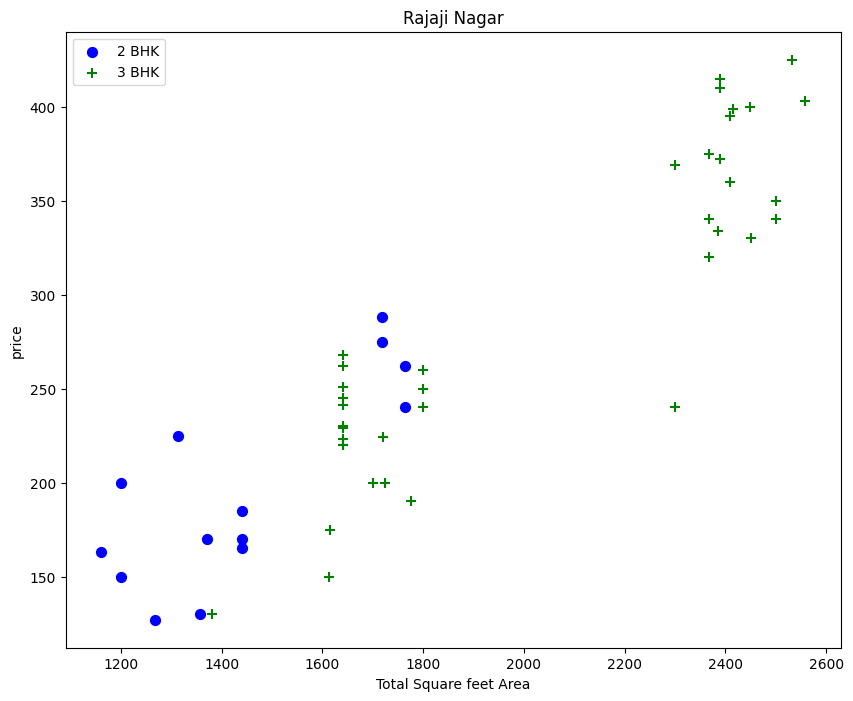

In [14]:
plot_scatter_chart(df7,"Rajaji Nagar")

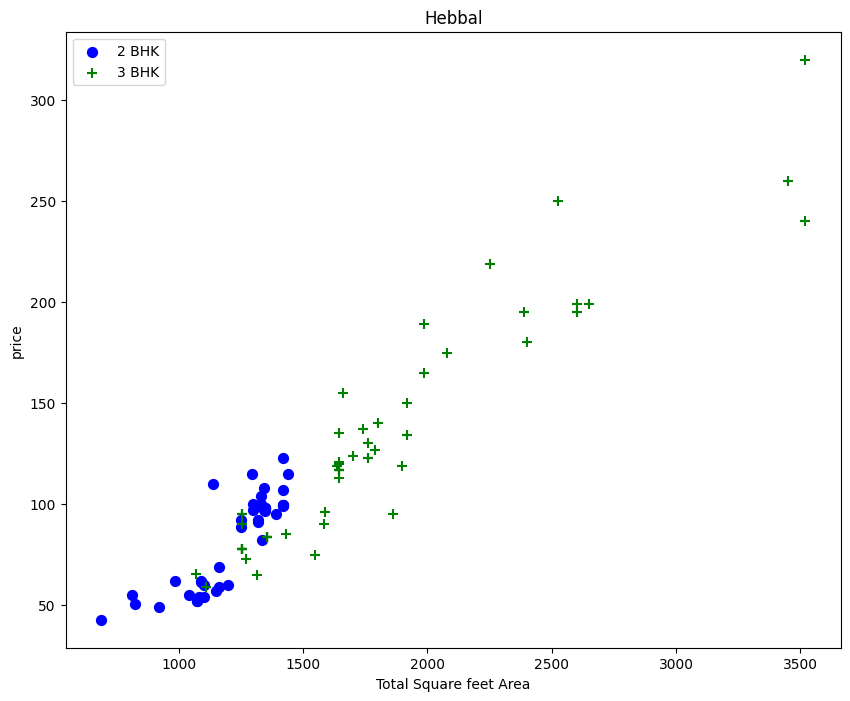

In [15]:
plot_scatter_chart(df7,"Hebbal")

In [16]:
def remove_bhk_outliers(df):
    exclude_indices = np.array([])

    # Group by location
    for location, location_df in df.groupby("location"):

        bhk_stats = {}
        
        # Compute mean, std, count for each BHK group
        for bhk, bhk_df in location_df.groupby("bhk"):
            bhk_stats[bhk] = {
                "mean": bhk_df["price_per_sqft"].mean(),
                "std": bhk_df["price_per_sqft"].std(),
                "count": bhk_df.shape[0]
            }

        # Use previous BHK mean to filter outliers
        for bhk, bhk_df in location_df.groupby("bhk"):
            prev_stats = bhk_stats.get(bhk - 1)

            if prev_stats and prev_stats["count"] > 5:
                # Outlier condition: price_per_sqft < mean of previous BHK
                bad_indices = bhk_df[
                    bhk_df["price_per_sqft"] < prev_stats["mean"]
                ].index.values

                exclude_indices = np.concatenate((exclude_indices, bad_indices))

    return df.drop(exclude_indices, axis="index")


In [17]:
df8 = remove_bhk_outliers(df7)
df8.shape

(7329, 7)

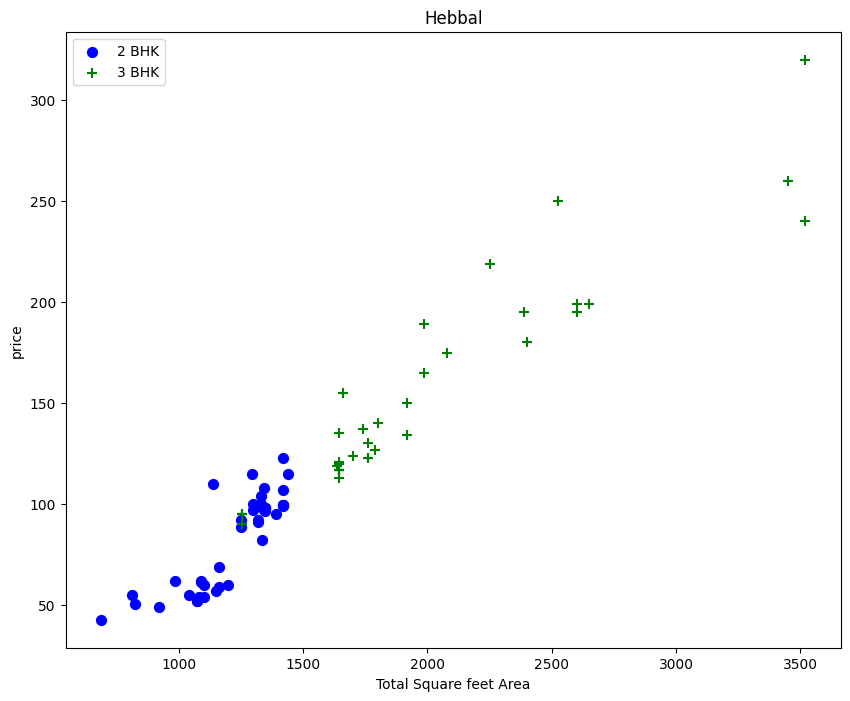

In [18]:
plot_scatter_chart(df8,"Hebbal")

Text(0, 0.5, 'Count')

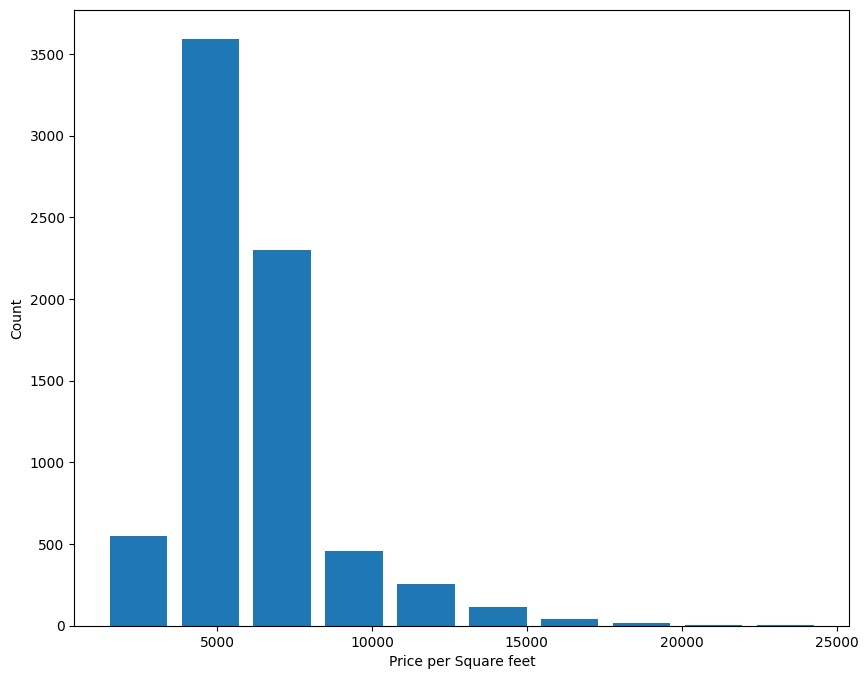

In [19]:
plt.figure(figsize=(10,8))
plt.hist(df8["price_per_sqft"],rwidth=0.8)
plt.xlabel("Price per Square feet")
plt.ylabel("Count")

In [20]:
df8["bath"].unique()

array([ 4.,  3.,  2.,  5.,  8.,  1.,  6.,  7.,  9., 12., 16., 13.])

In [21]:
df8[df8["bath"] > 10]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
5277,Neeladri Nagar,10 BHK,4000.0,12.0,160.0,10,4000.000000
8486,other,10 BHK,12000.0,12.0,525.0,10,4375.000000
8575,other,16 BHK,10000.0,16.0,550.0,16,5500.000000
9308,other,11 BHK,6000.0,12.0,150.0,11,2500.000000
9639,other,13 BHK,5425.0,13.0,275.0,13,5069.124424


Text(0, 0.5, 'Count')

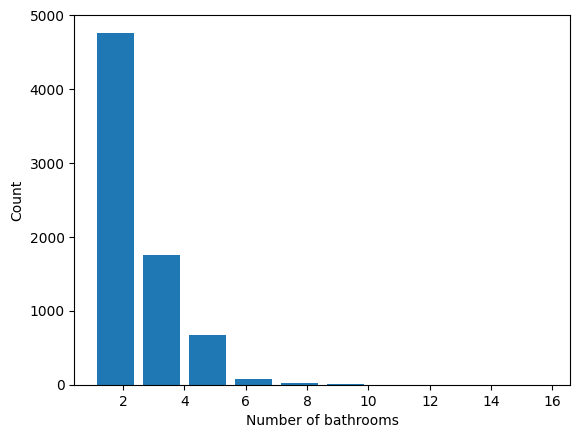

In [22]:
plt.hist(df8["bath"],rwidth=0.8)
plt.xlabel("Number of bathrooms")
plt.ylabel("Count")

In [23]:
df8[df8["bath"] > df8["bhk"]+ 2]

,location,size,total_sqft,bath,price,bhk,price_per_sqft
1626,Chikkabanavar,4 Bedroom,2460.0,7.0,80.0,4,3252.032520
5238,Nagasandra,4 Bedroom,7000.0,8.0,450.0,4,6428.571429
6711,Thanisandra,3 BHK,1806.0,6.0,116.0,3,6423.034330
8411,other,6 BHK,11338.0,9.0,1000.0,6,8819.897689


In [24]:
df9=df8[df8["bath"] < (df8["bhk"]+ 2)]
df9.shape

(7251, 7)

In [25]:
df10=df9.drop(["size","price_per_sqft"],axis="columns")
df10.head(3)

,location,total_sqft,bath,price,bhk
0,1st Block Jayanagar,2850.0,4.0,428.0,4
1,1st Block Jayanagar,1630.0,3.0,194.0,3
2,1st Block Jayanagar,1875.0,2.0,235.0,3


In [26]:
df10.to_csv("OutlierRemoval.csv",index="False")